# Implied Vol Fit

Author: Sebastien Gurrieri, sebgur@gmail.com

This notebook illustrates the implied vol functionalities in the SDevPy library. In its current state, it uses as example the first model in [[Gurrieri 2010]](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=1779463).

Named 'TsSvi1' for "Term-Structure SVI 1", this model is essentially the original SVI model by J. Gatheral at each expiry, but where the SVI parameters are parametric functions of time. It is thus a global model for the implied vol surface, calibrated to all options at once. For more details on the properties of this model, see reference above.

In [1]:
# Import relevant modules
import datetime as dt
import numpy as np
from platform import python_version
import matplotlib.pyplot as plt
import sdevpy as sd
from sdevpy.market import eqvolsurface as vsurf
from sdevpy.volatility.impliedvol.models.tssvi1 import TsSvi1
from sdevpy.volatility.impliedvol.impliedvol_calib import TsIvCalibrator
from sdevpy.volatility.localvol.dupire import calib_lv_dupire
from sdevpy.utilities import timegrids
from sdevpy.maths.metrics import rmse


print("Python version: " + python_version())
print("NumPy version: " + np.__version__)
print("SDevPy version: " + sd.__version__)

Python version: 3.14.0
NumPy version: 2.3.5
SDevPy version: 1.0.5


### Retrieve market data
The SDevPy library has a set of minimalistic market data files containing sample data. Beware that it contains toy data only, to be used strictly for illustration purposes. The data necessary for fitting, which is the expiries, the forwards, the strikes and the volatilities, are all contained in 1 file (per valuation date) and retrieved in an object (dictionary). The user can use the model simply by re-creating that object from their own data.

In [2]:
name = "ABC"
valdate = dt.datetime(2025, 12, 15)

# Retrieve market option data object
file = vsurf.data_file(name, valdate)
mkt_data = vsurf.eqvolsurfacedata_from_file(file)
print(f"Retrieved market data from file {file}")

# Access data in object
expiries = mkt_data.expiries
fwds = mkt_data.forwards
strikes = mkt_data.get_strikes('absolute')
mkt_vols = mkt_data.vols

# Quick check of size consistency
print(f"Number of expiries: {len(expiries)}")
print(f"Number of forwards: {len(fwds)}")
print(f"Number of strike sections: {len(strikes)}")
print(f"Number of vol sections: {len(mkt_vols)}")
for i in range(len(expiries)):
    print(f"Expiry {i+1} number of strikes/vols: {len(strikes[i])}/{len(mkt_vols[i])}")

Retrieved market data from file C:\Code\SDev.Python\datasets\marketdata\eqoptions\ABC\20251215-000000.json
Number of expiries: 6
Number of forwards: 6
Number of strike sections: 6
Number of vol sections: 6
Expiry 1 number of strikes/vols: 5/5
Expiry 2 number of strikes/vols: 5/5
Expiry 3 number of strikes/vols: 5/5
Expiry 4 number of strikes/vols: 5/5
Expiry 5 number of strikes/vols: 5/5
Expiry 6 number of strikes/vols: 5/5


In [3]:
# Initialize model
iv_surface = TsSvi1()

# Calibrate model
calibrator = TsIvCalibrator(iv_surface, {'optimizer': 'SLSQP', 'tol': 1e-6})
calibrator.calibrate(mkt_data)

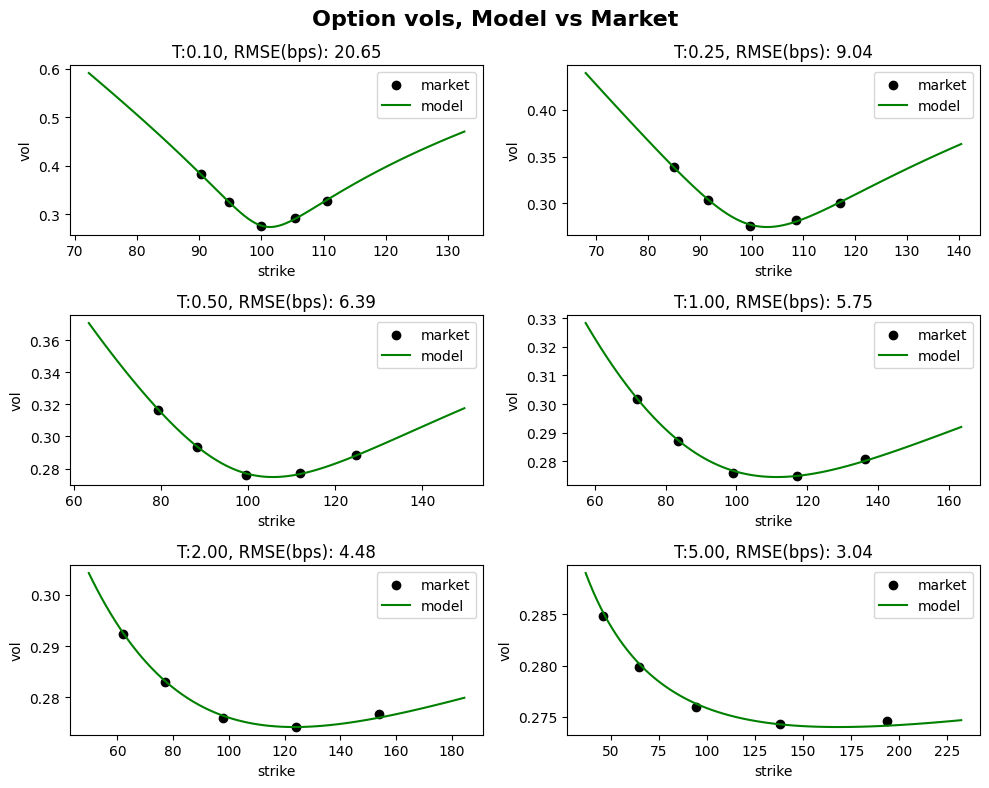

In [4]:
# Estimate model on points and calculate RMSE, plot comparison
n_rows, n_cols = 3, 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 8))
for i in range(n_rows):
    for j in range(n_cols):
        ax = axes[i, j]
        exp_idx = n_cols * i + j
        # expiry = expiry_grid[exp_idx]
        expiry = timegrids.model_time(valdate, expiries[exp_idx])
        fwd = fwds[exp_idx]
        exp_strikes = strikes[exp_idx]
        min_k, max_k = exp_strikes[0], exp_strikes[-1]
        m_strikes = np.linspace(0.8 * min_k, 1.2 * max_k, 100)
        m_vols = iv_surface.calculate(expiry, m_strikes, True, fwd)
        ax.scatter(exp_strikes, mkt_vols[exp_idx], label="market", color='black')
        ax.plot(m_strikes, m_vols, label="model", color='green')
        model_vols = iv_surface.calculate(expiry, exp_strikes, True, fwd)
        vol_rmse = rmse(mkt_vols[exp_idx], model_vols)
        ax.set_title(f"T:{expiry:.2f}, RMSE(bps): {10000.0 * vol_rmse:,.2f}")
        ax.set_xlabel('strike')
        ax.set_ylabel('vol')
        ax.legend()

fig.suptitle('Option vols, Model vs Market', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### Local Vol Calibration (Dupire)
Now we use the implied volatility surface calibrated to market data in the previous section to derive the corresponding local volatility using the Dupire method.

In [5]:
lv_calib = calib_lv_dupire(iv_surface, None, None, points_per_year=4, verbose=True)
lv = lv_calib['lv']
m = lv_calib['moneyness']
t = lv_calib['t_grid']

In [8]:
from sdevpy.utilities.algos import upper_bound
print(t)

t_plot = [1.0 / 12.0, 0.25, 0.5, 0.75, 1.0, 2.0]
t_idx = [upper_bound(t, tp) for tp in t_plot]
t_plot = t[t_idx]
print(t_plot)

[0.         0.00273973 0.01917808 0.03835616 0.08219178 0.28571429
 0.57142857 0.85714286 1.         1.14285714 1.42857143 1.71428571
 2.        ]
[0.28571429 0.28571429 0.57142857 0.85714286 1.         2.        ]


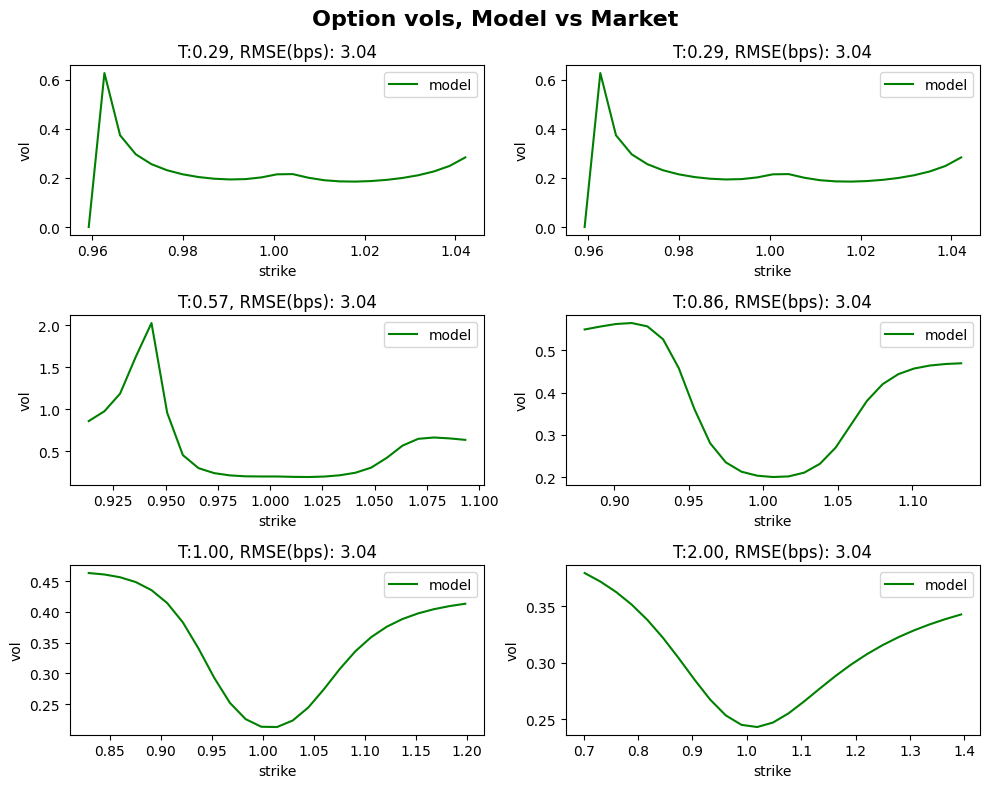

In [ ]:
# View the LV along the strike at several expiries
n_rows, n_cols = 3, 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 8))
for i in range(n_rows):
    for j in range(n_cols):
        ax = axes[i, j]
        exp_idx = n_cols * i + j
        expiry = t_plot[exp_idx]
        ax.plot(m[exp_idx], lv[exp_idx], label="model", color='green')
        ax.set_title(f"T:{expiry:.2f}")
        ax.set_xlabel('strike')
        ax.set_ylabel('local vol')
        ax.legend()

fig.suptitle('Option vols, Model vs Market', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# View LV along the expiry at several moneynesses
n_rows, n_cols = 3, 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 8))
for i in range(n_rows):
    for j in range(n_cols):
        ax = axes[i, j]
        exp_idx = n_cols * i + j
        expiry = t_plot[exp_idx]
        ax.plot(m[exp_idx], lv[exp_idx], label="model", color='green')
        ax.set_title(f"T:{expiry:.2f}")
        ax.set_xlabel('strike')
        ax.set_ylabel('local vol')
        ax.legend()

fig.suptitle('Option vols, Model vs Market', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


### Compare against MC and PDE prices